In [1]:
library(tidyverse)
library(ggplot2)

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖

In [2]:
#load the file with the R2 score for each of the phenotypes and the different p value thresholds
r2_df <- read_csv("/local1/scratch/pazweifel/PRS/jolien_common_factor/R_squared_ukbb.csv", col_names = TRUE)

New names:
• `` -> `...1`
Rows: 4823 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): phenotype, prs, type
dbl (5): ...1, R2_null, R2_full, delta_R2, N

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
r2_df <- rename(r2_df, Index = ...1)

In [4]:
head(r2_df)

Index,phenotype,prs,type,R2_null,R2_full,delta_R2,N
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,age,Pt_5e-08,continuous,0.002977847,0.002979803,1.956000e-06,337126
2,age,Pt_1e-05,continuous,0.002977847,0.002990677,1.283016e-05,337126
3,age,Pt_5e-05,continuous,0.002977847,0.003004098,2.625067e-05,337126
4,age,Pt_0.0001,continuous,0.002977847,0.003010207,3.235963e-05,337126
5,age,Pt_0.001,continuous,0.002977847,0.003037690,5.984334e-05,337126
6,age,Pt_0.01,continuous,0.002977847,0.003057851,8.000450e-05,337126


In [5]:
summary_r2_df_factor <- r2_df %>% group_by(phenotype) %>% slice_max(order_by = delta_R2, n = 1) %>% ungroup() %>% arrange(desc(delta_R2)) %>% mutate(phenotype = factor(phenotype, levels = phenotype))

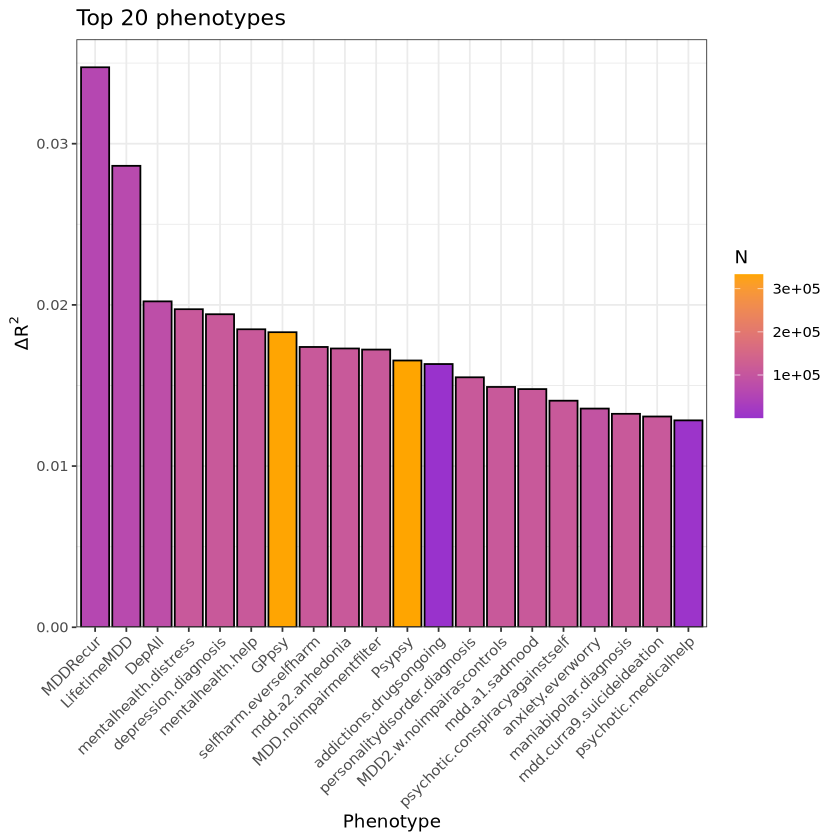

In [6]:
top20 <- ggplot(summary_r2_df_factor[1:20,], aes(x = phenotype, y = delta_R2, fill = N)) +
geom_col(color = "black") +
theme_bw() + 
theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
scale_fill_continuous(palette = c("darkorchid", "orange")) + 
labs(y = expression(Delta*R^2), x = "Phenotype", title = "Top 20 phenotypes") +
scale_y_continuous(expand = expansion(mult = c(0, 0.05)))

    
top20

In [7]:
ggsave("/local1/home/pazweifel/plots/jolien_paper/PRS_common_factor_top_20.pdf", plot = top20, device = pdf)

Saving 6.67 x 6.67 in image


# MDD PRS results

In [8]:
r2_df_mdd <- read_csv("/local1/scratch/pazweifel/PRS/MDD_Adams_25/R_squared_ukbb.csv", col_names = TRUE)

New names:
• `` -> `...1`
Rows: 4823 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): phenotype, prs, type
dbl (5): ...1, R2_null, R2_full, delta_R2, N

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [9]:
r2_df_mdd <- rename(r2_df_mdd, Index = ...1)

In [10]:
summary_r2_df_mdd <- r2_df_mdd %>% group_by(phenotype) %>% slice_max(order_by = delta_R2, n = 1) %>% ungroup() %>% arrange(desc(delta_R2)) %>% mutate(phenotype = factor(phenotype, levels = phenotype))

In [11]:
head(summary_r2_df_mdd, n= 20)

Index,phenotype,prs,type,R2_null,R2_full,delta_R2,N
<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
4700,MDDRecur,Pt_0.05,binary,0.0023205982,0.03273129,0.03041070,59379
4687,LifetimeMDD,Pt_0.05,binary,0.0021973949,0.02711622,0.02491883,67164
1944,depression.diagnosis,Pt_0.05,binary,0.0011570938,0.02084925,0.01969216,110352
4713,GPpsy,Pt_0.05,binary,0.0005809806,0.01849313,0.01791215,332551
1814,mentalhealth.distress,Pt_0.05,binary,0.0009892936,0.01865744,0.01766815,108929
1801,mentalhealth.help,Pt_0.05,binary,0.0005405762,0.01774636,0.01720578,109972
4740,DepAll,Pt_0.1,binary,0.0009861071,0.01816510,0.01717899,79564
4804,MDD.noimpairmentfilter,Pt_0.05,binary,0.0014944322,0.01725214,0.01575771,110153
2388,mdd.a2.anhedonia,Pt_0.2,binary,0.0015504975,0.01694921,0.01539871,110012


In [12]:
summary_r2_df_factor

Index,phenotype,prs,type,R2_null,R2_full,delta_R2,N
<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
4702,MDDRecur,Pt_0.2,binary,0.0023205982,0.03706089,0.03474029,59379
4690,LifetimeMDD,Pt_0.3,binary,0.0021973949,0.03082250,0.02862510,67164
4742,DepAll,Pt_0.3,binary,0.0009861071,0.02120324,0.02021714,79564
1817,mentalhealth.distress,Pt_0.3,binary,0.0009892936,0.02072077,0.01973147,108929
1946,depression.diagnosis,Pt_0.2,binary,0.0011570938,0.02057669,0.01941960,110352
1804,mentalhealth.help,Pt_0.3,binary,0.0005405762,0.01902757,0.01848699,109972
4715,GPpsy,Pt_0.2,binary,0.0005809806,0.01888620,0.01830522,332551
4157,selfharm.everselfharm,Pt_0.3,binary,0.0019665896,0.01935603,0.01738944,110023
2388,mdd.a2.anhedonia,Pt_0.2,binary,0.0015504975,0.01884634,0.01729584,110012


In [13]:
#extract the delta_R2 value of MDDRecur (top hit for both) and standardize all values by that, make a new column "delta_R2_scaled"
summary_r2_df_factor$delta_R2_scaled <- summary_r2_df_factor$delta_R2 / max(summary_r2_df_factor$delta_R2)
summary_r2_df_mdd$delta_R2_scaled <- summary_r2_df_mdd$delta_R2 / max(summary_r2_df_mdd$delta_R2)

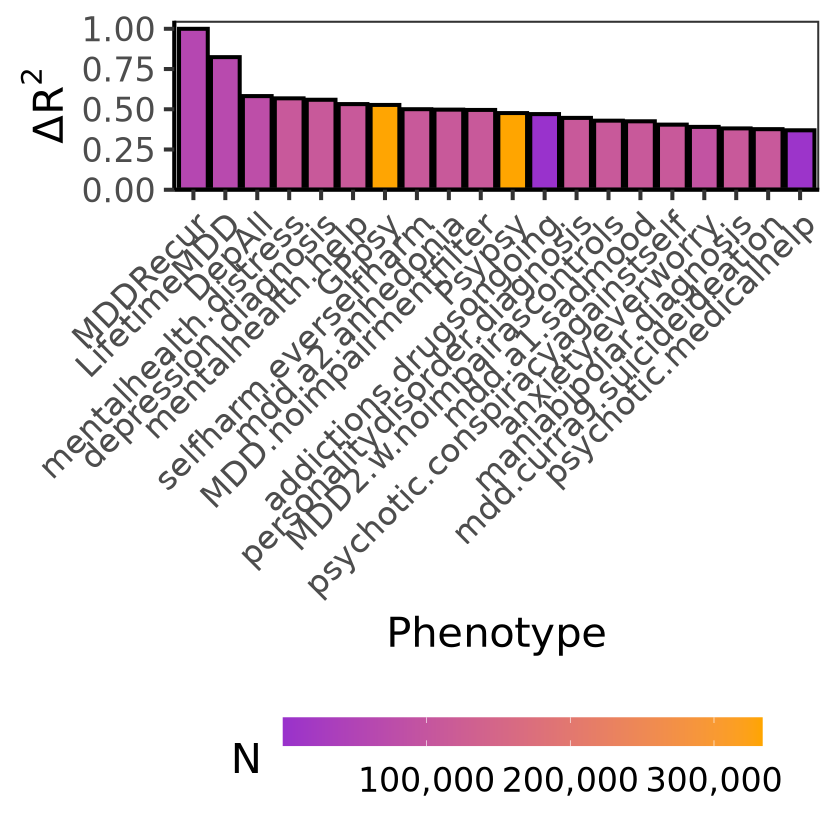

In [14]:
top20_scaled_factor <- ggplot(summary_r2_df_factor[1:20,], 
                             aes(x = phenotype, y = delta_R2_scaled, fill = N)) +
  geom_col(color = "black") +
  theme_bw(base_size = 25) + 
  theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(angle = 45, hjust = 1),
       legend.position = "bottom") +
  scale_fill_continuous(
    palette = c("darkorchid", "orange"),
    labels = scales::label_comma()
  ) + 
  labs(y = expression(Delta*R^2), x = "Phenotype") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
guides(fill = guide_colorbar(barwidth = 20))

top20_scaled_factor

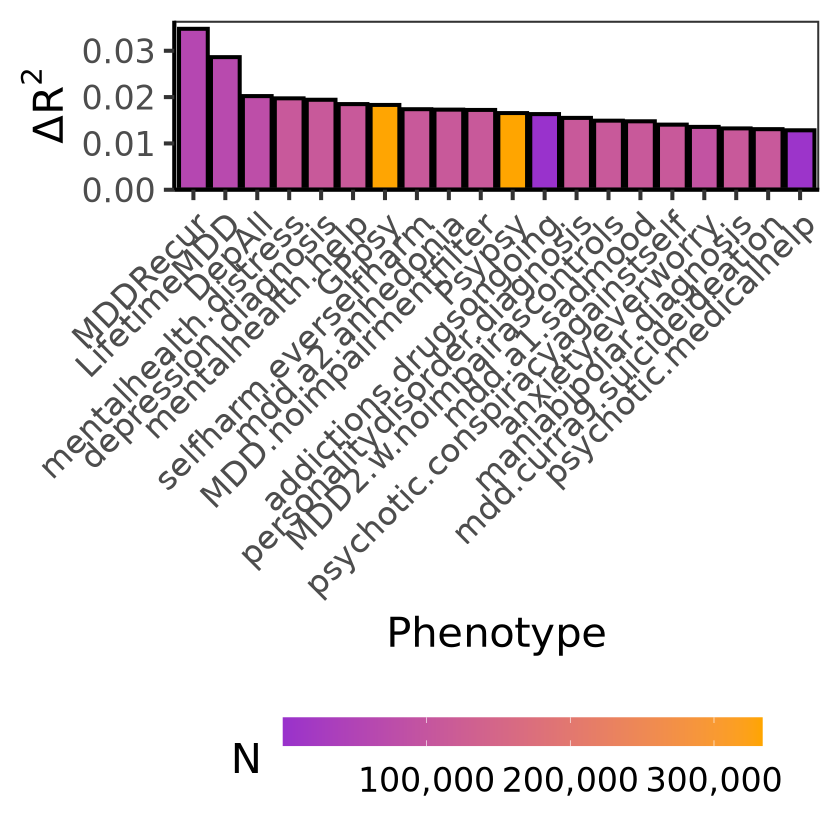

In [15]:
top20_factor <- ggplot(summary_r2_df_factor[1:20,], 
                             aes(x = phenotype, y = delta_R2, fill = N)) +
  geom_col(color = "black") +
  theme_bw(base_size = 25) + 
  theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        axis.line = element_line(colour = "black"), 
        axis.text.x = element_text(angle = 45, hjust = 1),
       legend.position = "bottom") +
  scale_fill_continuous(
    palette = c("darkorchid", "orange"),
    labels = scales::label_comma()
  ) + 
  labs(y = expression(Delta*R^2), x = "Phenotype") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
guides(fill = guide_colorbar(barwidth = 20))

top20_factor

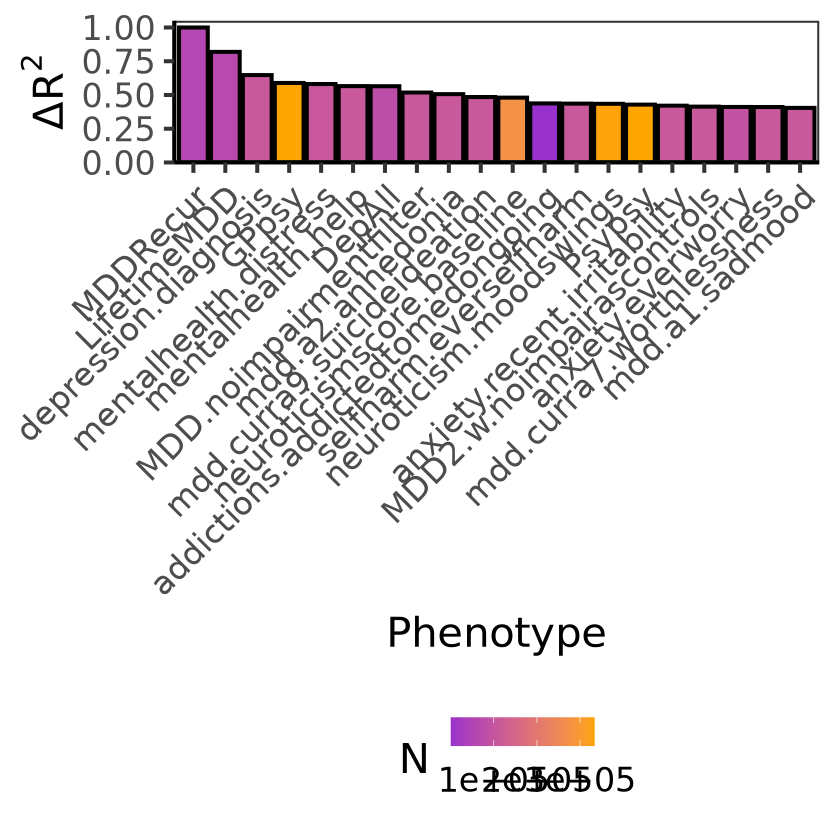

In [16]:
top20_scaled_mdd <- ggplot(summary_r2_df_mdd[1:20,], aes(x = phenotype, y = delta_R2_scaled, fill = N)) +
geom_col(color = "black") +
theme_bw(base_size = 25) + 
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), 
     axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "bottom") +
scale_fill_continuous(palette = c("darkorchid", "orange")) + 
labs(y = expression(Delta*R^2), x = "Phenotype") +
scale_y_continuous(expand = expansion(mult = c(0, 0.05)))

    
top20_scaled_mdd

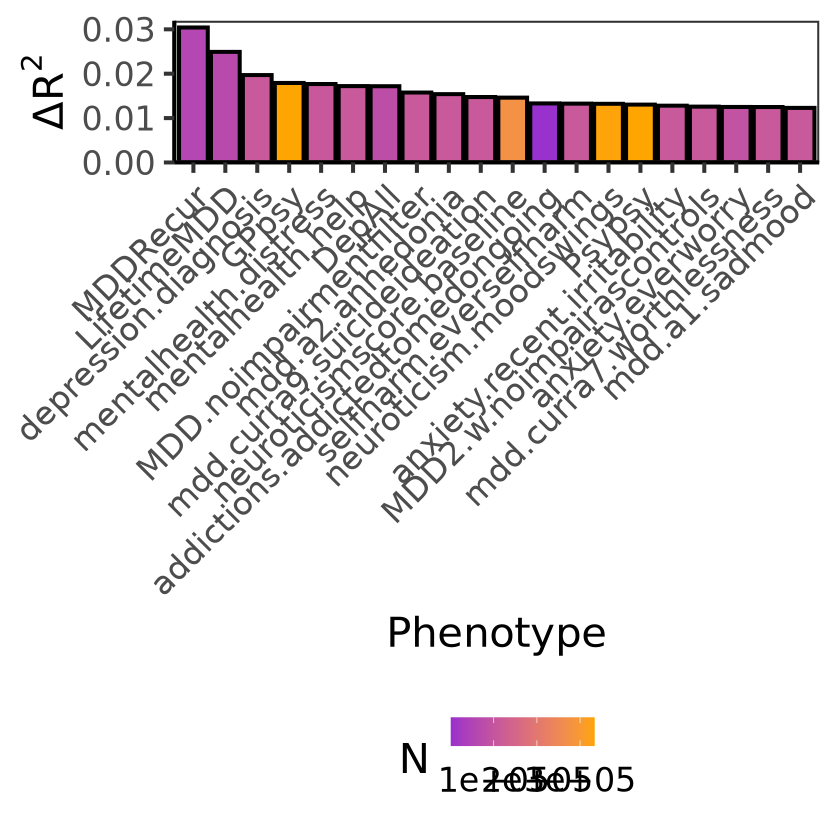

In [17]:
top20_mdd <- ggplot(summary_r2_df_mdd[1:20,], aes(x = phenotype, y = delta_R2, fill = N)) +
geom_col(color = "black") +
theme_bw(base_size = 25) + 
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), 
     axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "bottom") +
scale_fill_continuous(palette = c("darkorchid", "orange")) + 
labs(y = expression(Delta*R^2), x = "Phenotype") +
scale_y_continuous(expand = expansion(mult = c(0, 0.05)))

    
top20_mdd

In [18]:
library(cowplot)


Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




In [19]:
common_legend <- get_legend(top20_scaled_factor)

top20_scaled_factor_wo_legend <- top20_scaled_factor + theme(legend.position = "none")
top20_scaled_mdd_wo_legend <- top20_scaled_mdd + theme(legend.position = "none")

combined_plot <- plot_grid(plotlist = list(top20_scaled_factor_wo_legend, top20_scaled_mdd_wo_legend), ncol = 2, label_size = 18)

combined_plot_wlegend <- plot_grid(plotlist = list(combined_plot, common_legend), nrow = 2, rel_heights = c(1, 0.1))

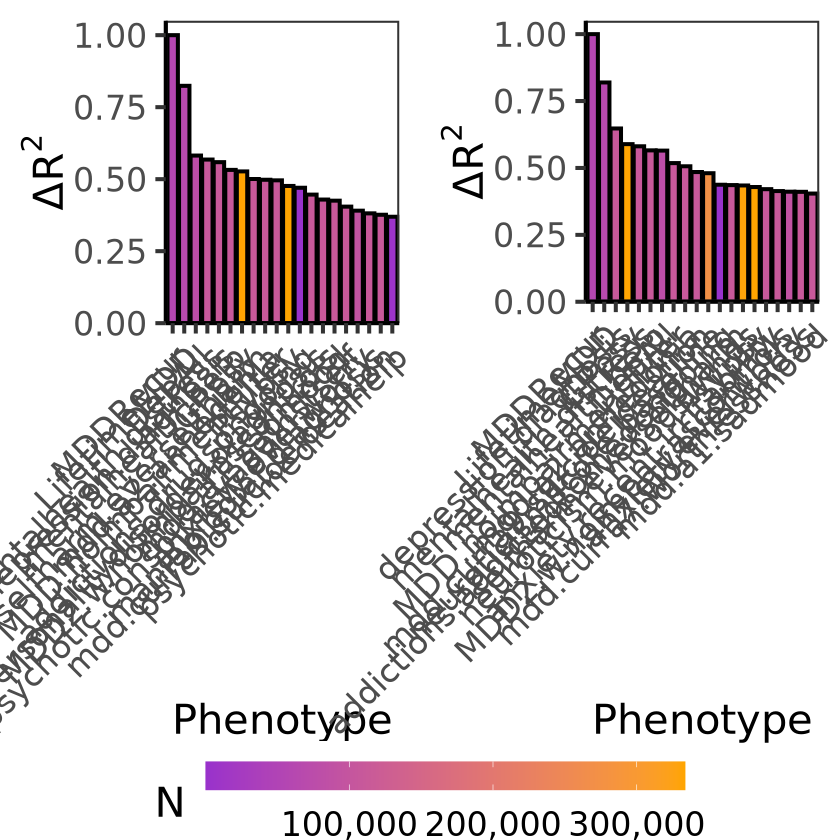

In [20]:
combined_plot_wlegend

In [21]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/factor_mdd_PRS_comparison_scaled.pdf", combined_plot_wlegend, device = pdf, height = 12, width = 20,  useDingbats = FALSE)

In [22]:
summary_r2_df_mdd_adj <- summary_r2_df_mdd
summary_r2_df_mdd_adj$Predictor <- "MDD"
summary_r2_df_factor_adj <- summary_r2_df_factor
summary_r2_df_factor_adj$Predictor <- "P_Factor"

In [23]:
combined_prs_results <- bind_rows(summary_r2_df_mdd_adj, summary_r2_df_factor_adj)

In [24]:
write_csv(combined_prs_results, "/local1/home/pazweifel/plots/jolien_extra_bias/combined_prs_results.csv")

### Overlap between top 20 

In [25]:
length(intersect(summary_r2_df_mdd[1:20,]$phenotype, summary_r2_df_factor[1:20,]$phenotype))

[1] 15